# Imports

In [2]:
import glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.insert(0,"/user/work/kr21883/acrg/")
sys.path.append("/user/work/kr21883/acrg/")
import acrg.obs as getobs
from acrg.hbmcmc.run_hbmcmc import hbmcmc_extract_param
import acrg.name.name as name

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
from acrg.hbmcmc.run_hbmcmc import extract_mcmc_type,define_mcmc_function

/user/home/kr21883/miniconda3/envs/acrg/lib/python3.10/site-packages/arviz/data/base.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
from acrg.hbmcmc.run_hbmcmc import extract_mcmc_type,define_mcmc_function

# Functions

In [5]:
def get_inversion_estimates(folder_path, run_name, run_type="MAP", spec=None, year=2016, country="BRAZIL", uncertainty="95", return_unc=False):
    # this should get renamed to get estimates!! it only gets MAP estimates if spec=MAP
    months = ["01","02", "03", "04", "05", "06", "07", "08","09", "10", "11", "12"]
    estimates = np.zeros((12,))
    uncertainties = np.zeros((12,2))
    uncertainties = np.where(uncertainties==0, np.nan, uncertainties)
    if spec is None:
        path = f"{folder_path}/CH4_*{run_name}_{year}"
    else:
        path = f"{folder_path}/CH4_*{run_name}-fps_{spec}_{year}"
    #print(path)
    for i, month in enumerate(months):
        #print(glob.glob(f"{path}-{month}-01.nc"))
        if len(glob.glob(f"{path}-{month}-01.nc")) == 1:
            try:
                d = xr.open_dataset(glob.glob(f"{path}-{month}-01.nc")[0])
                estimates[i] = d.sel(countrynames=country).countrymean.values
                if run_type!="MAP":
                    uncertainties[i,0] = d.sel(countrynames=country)[f"country{uncertainty}"].values[0]
                    uncertainties[i,1] = d.sel(countrynames=country)[f"country{uncertainty}"].values[1]
                d.close()
            except Exception as e:
                print(f"opening or extracting the data didnt work, for {month}!")
                print(f"with error {e}")
                print(f"maybe check path {path}")
        else:
            estimates[i] = np.nan
    if np.sum(np.isnan(estimates))==12:
        print("No months were loaded! check folder")
        print(path)
        
    if return_unc:        
        return estimates, uncertainties
    else:
        return estimates


def get_apriori(folder, run_name, spec=None, year=2016, uncertainty="95", country="MOROCCO"):
    months = ["01","02", "03", "04", "05", "06", "07", "08","09", "10", "11", "12"]
    apriori = np.zeros((12))
    if spec is None:
        path = f"/user/work/ef17148/acrg/satellite_outputs/NEW/SAHARA/{folder}/CH4_*{run_name}-fps_{year}"
    else:
        path = f"/user/work/ef17148/acrg/satellite_outputs/NEW/SAHARA/{folder}/CH4_*{run_name}-fps_{spec}_{year}"
    #print(path)
    for i, month in enumerate(months):
        files = glob.glob(f"{path}-{month}-01.nc")
        if len(files) > 1:
            files = [f for f in files if "-MAP-" not in f]
        
        if len(files) == 1:
            d = xr.open_dataset(glob.glob(f"{path}-{month}-01.nc")[0])
            apriori[i] = d.sel(countrynames=country).countryapriori.values
            d.close()
        else:
            apriori[i] = np.nan

    if np.sum(np.isnan(apriori))==12:
        print("No months were loaded! check folder")
        print(path)        
        
    return apriori

# Set up and run inversion

In [7]:
config_file = "/user/work/kr21883/acrg/acrg/bc_inversions/load_file_true.ini" ## Changed from Elena's path

In [8]:
month_dates = {"Jan":{"start_date":"2017-01-01","end_date":"2017-02-01"},
               "Feb":{"start_date":"2017-02-01","end_date":"2017-03-01"},
               "Mar":{"start_date":"2017-03-01","end_date":"2017-04-01"},
               "Apr":{"start_date":"2017-04-01","end_date":"2017-05-01"},
               "May":{"start_date":"2017-05-01","end_date":"2017-06-01"},
               "Jun":{"start_date":"2017-06-01","end_date":"2017-07-01"},
               "Jul":{"start_date":"2017-07-01","end_date":"2017-08-01"},
               "Aug":{"start_date":"2017-08-01","end_date":"2017-09-01"},
               "Sep":{"start_date":"2017-09-01","end_date":"2017-10-01"},
               "Oct":{"start_date":"2017-10-01","end_date":"2017-11-01"},
               "Nov":{"start_date":"2017-11-01","end_date":"2017-12-01"},
               "Dec":{"start_date":"2017-12-01","end_date":"2017-12-31"}}

In [9]:
month="Feb"

mcmc_type = extract_mcmc_type(config_file)
mcmc_function = define_mcmc_function(mcmc_type)
print(f"Using MCMC type: {mcmc_type} - function {mcmc_function.__name__}(...)")

param = hbmcmc_extract_param(config_file,mcmc_type, start_date=month_dates[month]["start_date"], end_date=month_dates[month]["end_date"])

Using MCMC type: MAP - function MAP(...)

Input parameters: 
species = ch4
sites = ['GOSAT-BRAZIL']
meas_period = [None]
max_level = 17
inlet = ['column']
instrument = None
obs_directory = None
domain = SOUTHAMERICA
met_model = None
fpheight = {'GOSAT-BRAZIL': 'column'}
emissions_name = {'all': 'ch4-all'}
fp_directory = /group/chem/acrg/LPDM/fp_NAME_pre20210701/
flux_directory = /group/chem/acrg/LPDM/emissions/
bc_directory = /group/chem/acrg/LPDM/bc/
bc_basis_case = uniform
fp_basis_case = None
quadtree_basis = True
nbasis = 100
basis_directory = None
load_emulated_bcs = False
emulated_bc_directory = /user/work/ef17148/GCN/graphnet/graph_weather/boundary_conds/
emulated_bc_filename = emulated_bc_basis_full
emulated_bc_attr_name = true_bc_flux
xprior = {'pdf': 'lognormal', 'mu': 1, 'sd': 1}
bcprior = {'pdf': 'truncatednormal', 'mu': 1, 'sd': 1, 'lower': 0}
sigprior = {'pdf': 'uniform', 'lower': 0.1, 'upper': 10}
bc_freq = None
sigma_freq = 5D
sigma_per_site = True
nit = 500000.0
burn =

In [10]:
param["outputname"] = "GOSAT-BRAZIL-LAND-TEST"

## Inversion

In [11]:
mcmc_function(**param)

Assuming status flag = 0 for all sites
Getting ch4 data for GOSAT-BRAZIL...
No lifetime defined in species_info.json or species not defined. WARNING: 30-day integrated footprint used without chemical loss.
Reading and concatenating files: 
/group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_201702.nc

Searching for flux files: /group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_*.nc
Reading and concatenating files: 
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2010_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2011_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2012_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2013_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2014_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/c


Post-processing output

Searching for flux files: /group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_*.nc
Reading and concatenating files: 
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2010_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2011_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2012_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2013_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2014_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2015_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2016_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2017_SWAMPS-v32-5_Saunois-Annual-Mean_copy

In [12]:
months_to_run = ["Jan", "Feb"]
#months_to_run = ["Jan", "Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for month in months_to_run:
    print(f"Running inversion for month: {month}")
    param = hbmcmc_extract_param(config_file,mcmc_type, start_date=month_dates[month]["start_date"], end_date=month_dates[month]["end_date"])
    mcmc_results = mcmc_function(**param)

Running inversion for month: Jan

Input parameters: 
species = ch4
sites = ['GOSAT-BRAZIL']
meas_period = [None]
max_level = 17
inlet = ['column']
instrument = None
obs_directory = None
domain = SOUTHAMERICA
met_model = None
fpheight = {'GOSAT-BRAZIL': 'column'}
emissions_name = {'all': 'ch4-all'}
fp_directory = /group/chem/acrg/LPDM/fp_NAME_pre20210701/
flux_directory = /group/chem/acrg/LPDM/emissions/
bc_directory = /group/chem/acrg/LPDM/bc/
bc_basis_case = uniform
fp_basis_case = None
quadtree_basis = True
nbasis = 100
basis_directory = None
load_emulated_bcs = False
emulated_bc_directory = /user/work/ef17148/GCN/graphnet/graph_weather/boundary_conds/
emulated_bc_filename = emulated_bc_basis_full
emulated_bc_attr_name = true_bc_flux
xprior = {'pdf': 'lognormal', 'mu': 1, 'sd': 1}
bcprior = {'pdf': 'truncatednormal', 'mu': 1, 'sd': 1, 'lower': 0}
sigprior = {'pdf': 'uniform', 'lower': 0.1, 'upper': 10}
bc_freq = None
sigma_freq = 5D
sigma_per_site = True
nit = 500000.0
burn = 50000
t


Post-processing output

Searching for flux files: /group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_*.nc
Reading and concatenating files: 
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2010_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2011_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2012_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2013_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2014_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2015_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2016_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2017_SWAMPS-v32-5_Saunois-Annual-Mean_copy


Post-processing output

Searching for flux files: /group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_*.nc
Reading and concatenating files: 
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2010_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2011_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2012_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2013_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2014_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2015_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2016_SWAMPS-v32-5_Saunois-Annual-Mean.nc
/group/chem/acrg/LPDM/emissions/SOUTHAMERICA/ch4-all_SOUTHAMERICA_2017_SWAMPS-v32-5_Saunois-Annual-Mean_copy

# Loading and plotting

In [13]:
load_runames = {"default":"default-test", "true subsampled":"true_bcs_subsampled", "pred subsampled":"pred_bcs_subsampled", "pred full":"GOSAT-BRAZIL-pred_bcs_full", "true full":"GOSAT-BRAZIL-true_bcs_full", "LAND pred full":"GOSAT-BRAZIL-LAND-pred_bcs_full", "LAND true full":"GOSAT-BRAZIL-LAND-true_bcs_full"}

In [14]:
estimates = {}
for runame in load_runames.keys():
    print(f"Loading inversion results for: {runame}")
    estimates_here = get_inversion_estimates("/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_MAP_experiments/", run_name=load_runames[runame], run_type="MAP", spec=None, year=2017, country="BRAZIL")
    estimates_here[estimates_here>1e17] = np.nan
    estimates[runame] = estimates_here/1e12

Loading inversion results for: default
No months were loaded! check folder
/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_MAP_experiments//CH4_*default-test_2017
Loading inversion results for: true subsampled
No months were loaded! check folder
/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_MAP_experiments//CH4_*true_bcs_subsampled_2017
Loading inversion results for: pred subsampled
No months were loaded! check folder
/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_MAP_experiments//CH4_*pred_bcs_subsampled_2017
Loading inversion results for: pred full
No months were loaded! check folder
/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_MAP_experiments//CH4_*GOSAT-BRAZIL-pred_bcs_full_2017
Loading inversion results for: true full
No months were loaded! check folder
/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_MAP_experiments//CH4_*GOSAT-BRAZIL-true_bcs_full_2017
Loading inversion results for: LAND pred full
No mont

In [15]:
full_estimates = {}
load_runames = {"pred full":"GOSAT-BRAZIL-pred_bcs", "true full":"GOSAT-BRAZIL-true_bcs", "LAND pred full":"GOSAT-BRAZIL-LAND-pred_bcs", "LAND true full":"GOSAT-BRAZIL-LAND-true_bcs"}
for runame in load_runames.keys():
    print(f"Loading inversion results for: {runame}")
    estimates_here, uncertainty = get_inversion_estimates("/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_inversion/", run_name=load_runames[runame], run_type="MCMC", spec=None, year=2017, country="BRAZIL", return_unc=True)
    estimates_here[estimates_here>1e17] = np.nan
    full_estimates[runame] = (estimates_here/1e12, uncertainty/1e12)

Loading inversion results for: pred full
No months were loaded! check folder
/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_inversion//CH4_*GOSAT-BRAZIL-pred_bcs_2017
Loading inversion results for: true full
No months were loaded! check folder
/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_inversion//CH4_*GOSAT-BRAZIL-true_bcs_2017
Loading inversion results for: LAND pred full
No months were loaded! check folder
/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_inversion//CH4_*GOSAT-BRAZIL-LAND-pred_bcs_2017
Loading inversion results for: LAND true full
No months were loaded! check folder
/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_inversion//CH4_*GOSAT-BRAZIL-LAND-true_bcs_2017


In [29]:
#br = xr.open_dataset("/user/work/ef17148/acrg/satellite_outputs/bc_inversions/first_MAP_experiments/CH4_SOUTHAMERICA_GOSAT-BRAZIL-LAND-true_bcs_full_2017-06-01.nc").sel(countrynames="BRAZIL")

br = xr.open_dataset("/user/work/kr21883/acrg/satellite_outputs/bc_inversions/first_inversion/CH4_SOUTHAMERICA_GOSAT-BRAZIL-true_bcs_2017-01-01.nc").sel(countrynames="BRAZIL")


In [30]:
def plot_estimates(dict_estimates, dict_full_estimates, est_to_plot, est_to_plot_full):
    fig, ax = plt.subplots(1,1, figsize=(8,5))
 
    for estimate_label in est_to_plot:
        p = ax.plot(np.arange(1,13), dict_estimates[estimate_label], label=estimate_label)
        ax.scatter(np.arange(1,13), dict_estimates[estimate_label], color=p[0].get_color())

    for estimate_label in est_to_plot_full:
        p = ax.plot(np.arange(1,13), dict_full_estimates[estimate_label][0], label=estimate_label)
        ax.scatter(np.arange(1,13), dict_full_estimates[estimate_label][0], color=p[0].get_color())
        # make fill_between the same color as plot
        ax.fill_between(np.arange(1,13), dict_full_estimates[estimate_label][1][:,0], dict_full_estimates[estimate_label][1][:,1], alpha=0.3, color=p[0].get_color())
    
    ax.set_xlabel("Month")
    ax.set_ylabel("Inversion Estimate (Tg CH4/month)")
    ax.set_title("Brazil Inversion Estimates 2017")
    ax.legend()
    plt.show()

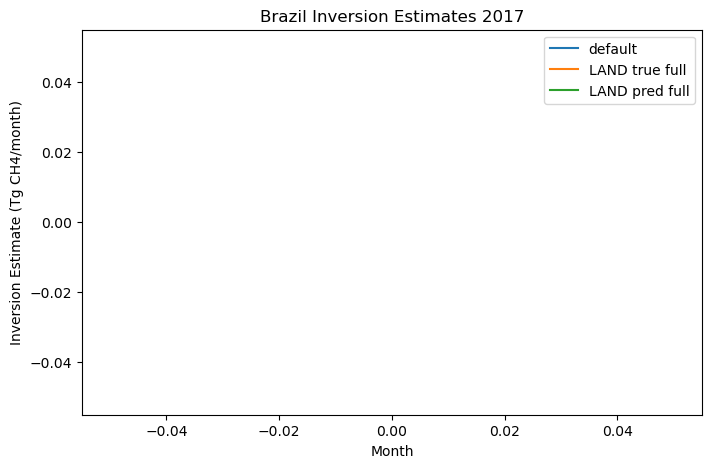

In [31]:
plot_estimates(estimates, {}, ["default", "LAND true full", "LAND pred full"], [])

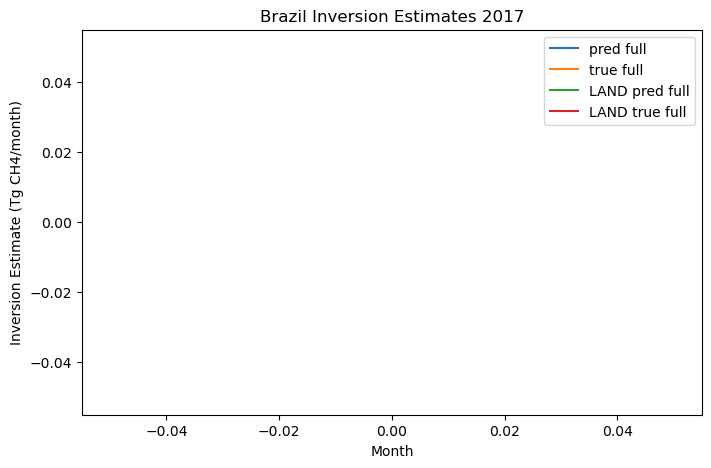

In [32]:
plot_estimates(estimates, full_estimates, [], ["pred full", "true full", "LAND pred full", "LAND true full"])

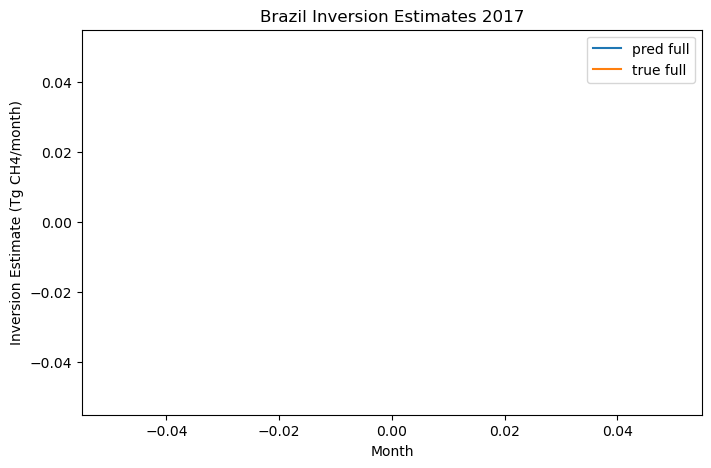

In [33]:
plot_estimates(estimates, full_estimates, [], ["pred full", "true full"])

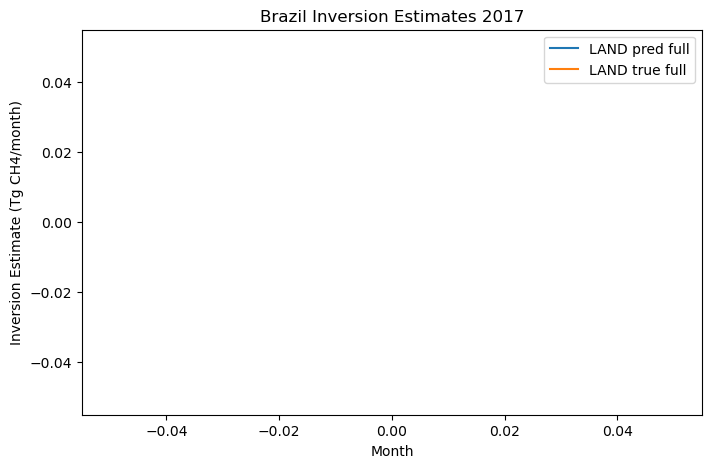

In [34]:
plot_estimates(estimates, full_estimates, [], ["LAND pred full", "LAND true full"])

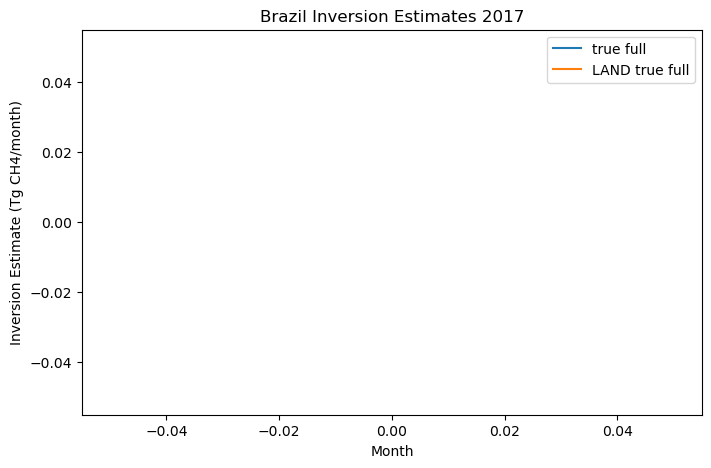

In [35]:
plot_estimates(estimates, full_estimates, [], ["true full", "LAND true full"])